# Week 6: Bayesian Reinforcement Learning I

**FYS4411 — Reinforcement Learning and Agentic AI**  
University of Oslo, Department of Physics

*Priors, posteriors, exploration, and regret*

This notebook is self-contained and executable. It combines a concise repetition of the lecture, equations, reproducible numerical examples, visual diagnostics, and a short problem set. No API key or external service is required.

In [1]:
import math
import re
from dataclasses import dataclass, field
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(6)
UIO_PURPLE = "#4338B5"
UIO_GREEN = "#2A9D8F"
UIO_RED = "#C84C4C"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8.5, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Learning goals

After completing this notebook, you should be able to

- update a prior distribution after observing data;
- distinguish posterior uncertainty from environmental randomness;
- implement Thompson sampling and an upper-confidence policy;
- interpret cumulative regret and posterior calibration;
- explain why uncertainty is useful only when it changes a decision.

## Repetition: Bayesian inference inside reinforcement learning

Bayesian inference treats an unknown quantity $\theta$ as a random variable. Given data $D$, Bayes' rule is

$$
p(\theta\mid D)=\frac{p(D\mid\theta)p(\theta)}{p(D)}
\propto p(D\mid\theta)p(\theta).
$$

In reinforcement learning, $\theta$ may represent a reward probability, a transition probability, a model parameter, a value, or a neural-network weight. The posterior is not an additional source of physical randomness: it represents what the agent does not yet know.

For a Bernoulli reward $R\in\{0,1\}$ and a Beta prior,

$$
\theta\sim\operatorname{Beta}(\alpha_0,\beta_0),\qquad
R_i\mid\theta\sim\operatorname{Bernoulli}(\theta),
$$

conjugacy gives

$$
\theta\mid D_n\sim\operatorname{Beta}(\alpha_0+s_n,\,\beta_0+n-s_n),
$$

where $s_n=\sum_{i=1}^nR_i$. The posterior predictive success probability is

$$
\Pr(R_{n+1}=1\mid D_n)=\frac{\alpha_0+s_n}{\alpha_0+\beta_0+n}.
$$

## Example 1: a posterior is a quantitative state of knowledge

Posterior mean: 0.667
95% credible interval: [0.390, 0.891]


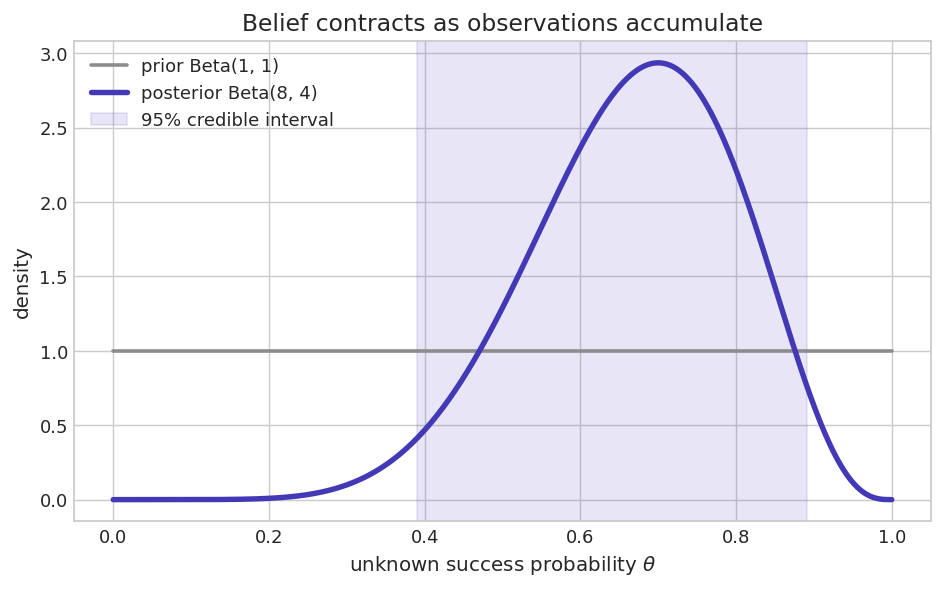

In [2]:
from scipy.stats import beta

observations = np.array([1, 0, 1, 1, 0, 1, 1, 1, 0, 1])
alpha0, beta0 = 1.0, 1.0
alpha_post = alpha0 + observations.sum()
beta_post = beta0 + len(observations) - observations.sum()

x = np.linspace(0, 1, 500)
prior_density = beta.pdf(x, alpha0, beta0)
posterior_density = beta.pdf(x, alpha_post, beta_post)
credible = beta.ppf([0.025, 0.975], alpha_post, beta_post)

plt.plot(x, prior_density, lw=2, color="0.55", label="prior Beta(1, 1)")
plt.plot(x, posterior_density, lw=3, color=UIO_PURPLE,
         label=f"posterior Beta({alpha_post:.0f}, {beta_post:.0f})")
plt.axvspan(*credible, color=UIO_PURPLE, alpha=0.12,
            label="95% credible interval")
plt.xlabel(r"unknown success probability $\theta$")
plt.ylabel("density")
plt.title("Belief contracts as observations accumulate")
plt.legend()
plt.show()

print(f"Posterior mean: {alpha_post/(alpha_post+beta_post):.3f}")
print(f"95% credible interval: [{credible[0]:.3f}, {credible[1]:.3f}]")

The interval is a statement about the unknown parameter under the specified model and prior. It is not a guarantee that 95% of future rewards lie inside the interval. Future rewards remain binary and noisy even if $\theta$ were known exactly.

## Bayesian exploration

A multi-armed bandit isolates the exploration problem. Arm $a$ has an unknown mean reward $\mu_a$. The agent chooses $A_t$, observes $R_{t+1}$, and seeks to maximize reward. A common performance measure is cumulative pseudo-regret,

$$
\mathcal R_T=\sum_{t=0}^{T-1}\left(\mu^*-\mu_{A_t}\right),
\qquad \mu^*=\max_a\mu_a.
$$

Two uncertainty-aware decision rules are:

**Thompson sampling**

$$
\widetilde\mu_a\sim p(\mu_a\mid D_t),\qquad
A_t=\arg\max_a\widetilde\mu_a.
$$

**Upper-confidence selection**

$$
A_t=\arg\max_a\left[\widehat\mu_a(t)+c\sqrt{\frac{\log(t+1)}{N_a(t)}}\right].
$$

Thompson sampling randomizes according to posterior plausibility. UCB is optimistic: it assigns value to an arm because its upper confidence estimate is high.

## Example 2: Thompson sampling, UCB, and uninformed exploration

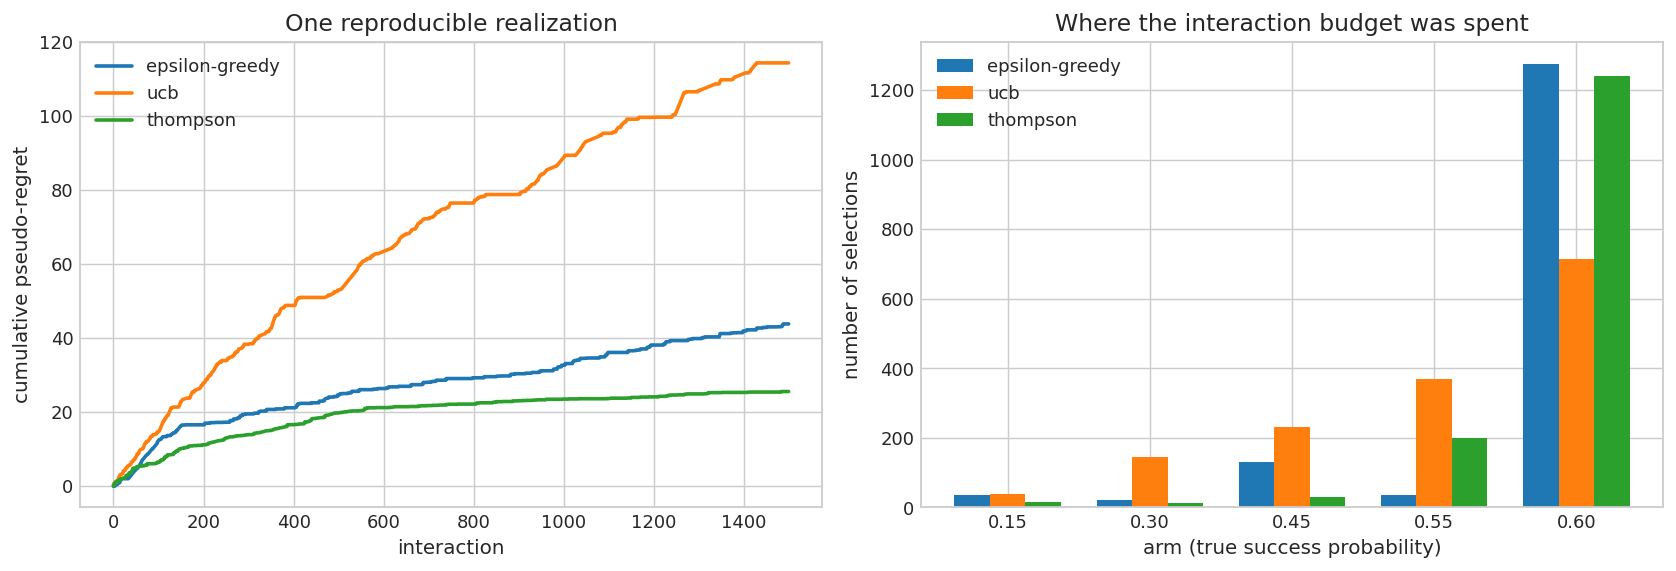

In [3]:
true_probabilities = np.array([0.15, 0.30, 0.45, 0.55, 0.60])

def run_bandit(method, horizon=1500, seed=0, epsilon=0.10, c=1.5):
    local_rng = np.random.default_rng(seed)
    n_arms = len(true_probabilities)
    counts = np.zeros(n_arms, dtype=int)
    successes = np.zeros(n_arms)
    alpha = np.ones(n_arms)
    beta_par = np.ones(n_arms)
    choices, rewards, pseudo_regret = [], [], []

    for t in range(horizon):
        if method == "epsilon-greedy":
            if local_rng.random() < epsilon or np.any(counts == 0):
                action = int(local_rng.integers(n_arms))
            else:
                action = int(np.argmax(successes / np.maximum(counts, 1)))
        elif method == "ucb":
            if t < n_arms:
                action = t
            else:
                means = successes / counts
                bonus = c * np.sqrt(np.log(t + 1) / counts)
                action = int(np.argmax(means + bonus))
        elif method == "thompson":
            samples = local_rng.beta(alpha, beta_par)
            action = int(np.argmax(samples))
        else:
            raise ValueError(method)

        reward = int(local_rng.random() < true_probabilities[action])
        counts[action] += 1
        successes[action] += reward
        alpha[action] += reward
        beta_par[action] += 1 - reward
        choices.append(action)
        rewards.append(reward)
        pseudo_regret.append(true_probabilities.max() - true_probabilities[action])

    return {
        "choices": np.asarray(choices),
        "rewards": np.asarray(rewards),
        "regret": np.cumsum(pseudo_regret),
        "counts": counts,
        "alpha": alpha,
        "beta": beta_par,
    }

methods = ["epsilon-greedy", "ucb", "thompson"]
results = {method: run_bandit(method, seed=12) for method in methods}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for method, result in results.items():
    axes[0].plot(result["regret"], lw=2, label=method)
axes[0].set_xlabel("interaction")
axes[0].set_ylabel("cumulative pseudo-regret")
axes[0].set_title("One reproducible realization")
axes[0].legend()

width = 0.25
arm_index = np.arange(len(true_probabilities))
for offset, method in enumerate(methods):
    axes[1].bar(arm_index + (offset - 1) * width,
                results[method]["counts"], width=width, label=method)
axes[1].set_xticks(arm_index, [f"{p:.2f}" for p in true_probabilities])
axes[1].set_xlabel("arm (true success probability)")
axes[1].set_ylabel("number of selections")
axes[1].set_title("Where the interaction budget was spent")
axes[1].legend()
plt.tight_layout()
plt.show()

### Averaging over seeds separates an algorithmic pattern from a lucky run

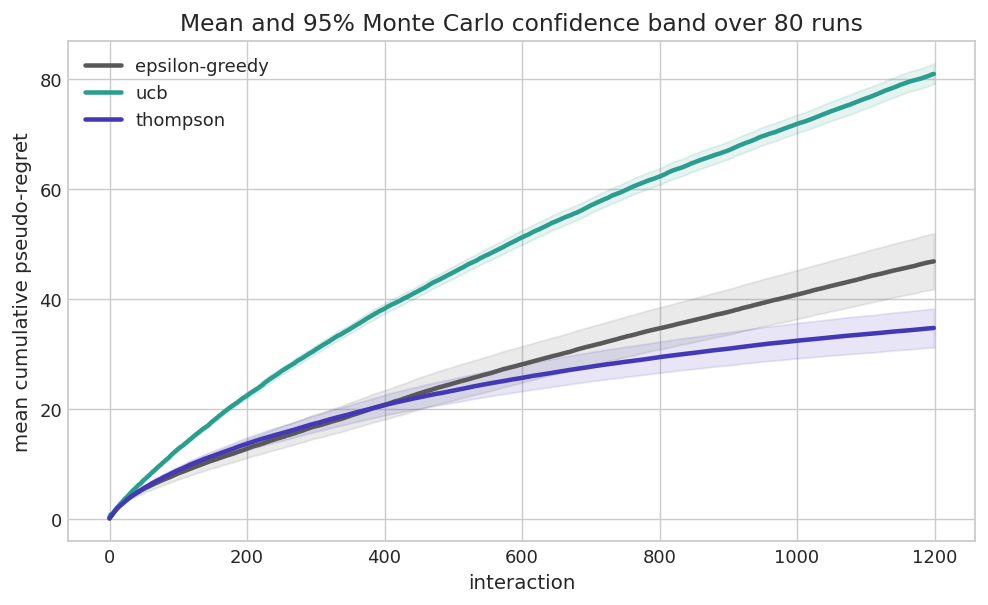

In [4]:
horizon = 1200
seeds = range(80)
regret_samples = {
    method: np.stack([run_bandit(method, horizon, seed=s)["regret"] for s in seeds])
    for method in methods
}

plt.figure(figsize=(9, 5))
colors = {"epsilon-greedy": "0.35", "ucb": UIO_GREEN, "thompson": UIO_PURPLE}
for method, samples in regret_samples.items():
    mean = samples.mean(axis=0)
    sem = samples.std(axis=0) / np.sqrt(len(samples))
    plt.plot(mean, lw=2.5, color=colors[method], label=method)
    plt.fill_between(np.arange(horizon), mean - 1.96 * sem, mean + 1.96 * sem,
                     color=colors[method], alpha=0.12)
plt.xlabel("interaction")
plt.ylabel("mean cumulative pseudo-regret")
plt.title("Mean and 95% Monte Carlo confidence band over 80 runs")
plt.legend()
plt.show()

## Example 3: inspect what Thompson sampling has learned

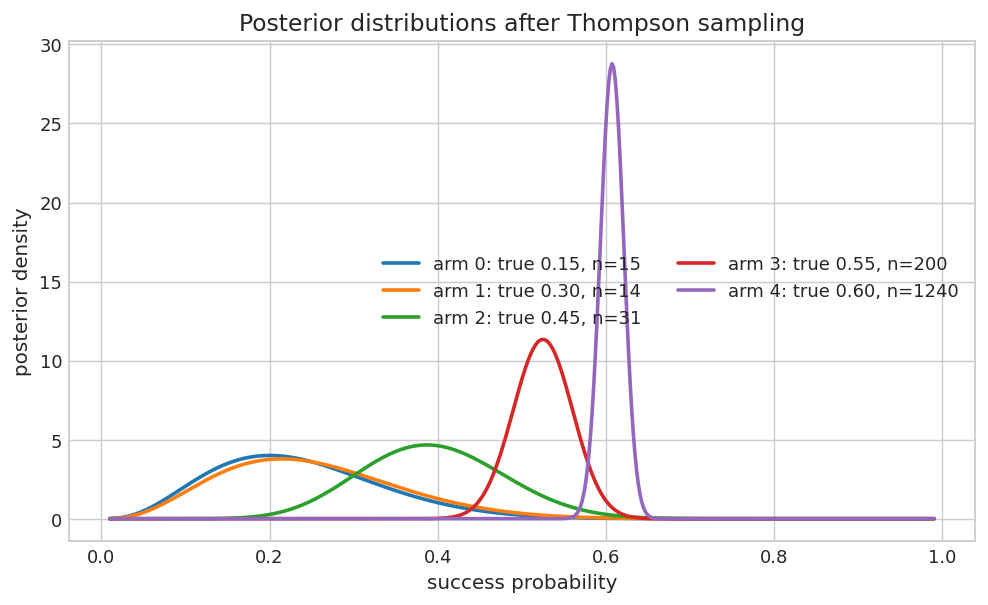

In [5]:
thompson = results["thompson"]
x = np.linspace(0.01, 0.99, 500)
plt.figure(figsize=(9, 5))
for arm, (a, b, truth) in enumerate(zip(thompson["alpha"], thompson["beta"], true_probabilities)):
    plt.plot(x, stats.beta.pdf(x, a, b), lw=2,
             label=f"arm {arm}: true {truth:.2f}, n={thompson['counts'][arm]}")
plt.xlabel("success probability")
plt.ylabel("posterior density")
plt.title("Posterior distributions after Thompson sampling")
plt.legend(ncol=2)
plt.show()

## Prior sensitivity and scientific judgement

Priors can encode previous experiments or physical bounds, but they can also delay correction when they are too concentrated. For a Beta prior, the quantity $\alpha_0+\beta_0$ behaves like a prior effective sample size. A responsible analysis should report the prior and test whether the decision changes under plausible alternatives.

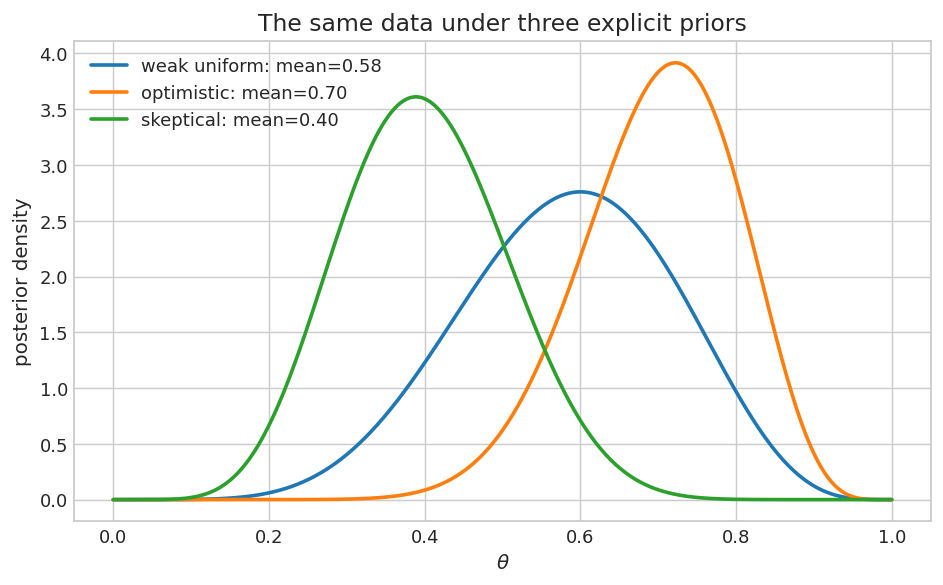

In [6]:
priors = {
    "weak uniform": (1, 1),
    "optimistic": (8, 2),
    "skeptical": (2, 8),
}
successes, failures = 6, 4
x = np.linspace(0, 1, 500)
for name, (a0, b0) in priors.items():
    a, b = a0 + successes, b0 + failures
    plt.plot(x, stats.beta.pdf(x, a, b), lw=2,
             label=f"{name}: mean={a/(a+b):.2f}")
plt.xlabel(r"$\theta$")
plt.ylabel("posterior density")
plt.title("The same data under three explicit priors")
plt.legend()
plt.show()

## Problem set

1. Starting from the Beta density and Bernoulli likelihood, derive the posterior parameters after $s$ successes and $f$ failures.
2. Show that the posterior variance of $\operatorname{Beta}(\alpha,\beta)$ decreases as the effective sample size grows while the mean is held fixed.
3. Modify the bandit so that pulling an arm has an arm-dependent cost. Define a net-reward objective and compare the selected arms.
4. Repeat the experiment with two nearly identical best arms. Why does identifying the unique best arm become statistically expensive?
5. In a laboratory setting, what would count as epistemic uncertainty, aleatoric uncertainty, and model misspecification?

**Extension.** Implement posterior sampling for an unknown transition probability in a two-state MDP. Sample a transition model at the start of each episode, solve that sampled MDP, and execute its policy for one episode.

## Summary

Bayesian RL places probability distributions over quantities the agent does not know. Posterior sampling and optimism use uncertainty to allocate interaction, but they do so differently. A posterior is useful when it is calibrated, decision-relevant, and tested for prior sensitivity. Week 7 extends this idea: the posterior itself becomes part of the agent's state.

**Further reading:** Sutton and Barto, *Reinforcement Learning* (bandits and exploration); Russo et al., *A Tutorial on Thompson Sampling*; the Bayesian RL lecture sequence supplied with the course.